# 01 — Data Understanding

This notebook prepares and explores the IBM AML transaction dataset.

Goals:
- Set up a reproducible Colab workspace
- Download the dataset only if missing
- Clean the raw transaction schema only if needed
- Save a fast Parquet version
- Load the clean dataset for EDA
- Understand class imbalance, transaction types, currencies, amounts, and time range

No modelling is done in this notebook.

In [31]:
!pip install -q kagglehub polars pandas numpy matplotlib pyarrow tqdm

In [2]:
from pathlib import Path
import shutil

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

In [3]:
# Project configuration

PROJECT_ROOT = Path("/content/drive/MyDrive/temporal-graph-aml")

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

KAGGLE_DATASET = "ealtman2019/ibm-transactions-for-anti-money-laundering-aml"

RAW_TRANSACTION_FILE_NAME = "HI-Small_Trans.csv"
RAW_TRANSACTION_PATH = RAW_DIR / RAW_TRANSACTION_FILE_NAME

CLEAN_TRANSACTIONS_PATH = PROCESSED_DIR / "hi_small_transactions_clean.parquet"

LABEL_COLUMN = "is_laundering"

# Change this to True only if you want to rebuild the clean Parquet from CSV
FORCE_REBUILD_CLEAN_DATA = False

In [4]:
from google.colab import drive

drive.mount("/content/drive")

for folder in [
    RAW_DIR,
    PROCESSED_DIR,
    REPORTS_DIR,
    FIGURES_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data folder: {RAW_DIR}")
print(f"Processed data folder: {PROCESSED_DIR}")

Mounted at /content/drive
Project root: /content/drive/MyDrive/temporal-graph-aml
Raw data folder: /content/drive/MyDrive/temporal-graph-aml/data/raw
Processed data folder: /content/drive/MyDrive/temporal-graph-aml/data/processed


In [5]:
import kagglehub

if RAW_TRANSACTION_PATH.exists():
    print(f"Raw transaction file already exists:\n{RAW_TRANSACTION_PATH}")
    print("Skipping Kaggle download.")
else:
    print("Raw transaction file not found. Downloading dataset from Kaggle...")

    dataset_cache_path = Path(kagglehub.dataset_download(KAGGLE_DATASET))

    for item in dataset_cache_path.iterdir():
        destination = RAW_DIR / item.name

        if item.is_dir():
            shutil.copytree(item, destination, dirs_exist_ok=True)
        else:
            shutil.copy2(item, destination)

    print(f"Dataset copied to:\n{RAW_DIR}")

    if not RAW_TRANSACTION_PATH.exists():
        raise FileNotFoundError(
            f"Expected file was not found after download: {RAW_TRANSACTION_PATH}"
        )

Raw transaction file already exists:
/content/drive/MyDrive/temporal-graph-aml/data/raw/HI-Small_Trans.csv
Skipping Kaggle download.


In [6]:
csv_files = sorted(RAW_DIR.rglob("*.csv"))

files_df = pd.DataFrame(
    [
        {
            "file_name": file_path.name,
            "path": str(file_path),
            "size_mb": round(file_path.stat().st_size / (1024 ** 2), 2),
        }
        for file_path in csv_files
    ]
).sort_values("size_mb")

files_df

,file_name,path,size_mb
5,HI-Small_accounts.csv,/content/drive/MyDrive/temporal-graph-aml/data...,32.48
11,LI-Small_accounts.csv,/content/drive/MyDrive/temporal-graph-aml/data...,45.06
9,LI-Medium_accounts.csv,/content/drive/MyDrive/temporal-graph-aml/data...,135.21
7,LI-Large_accounts.csv,/content/drive/MyDrive/temporal-graph-aml/data...,137.66
3,HI-Medium_accounts.csv,/content/drive/MyDrive/temporal-graph-aml/data...,138.29
1,HI-Large_accounts.csv,/content/drive/MyDrive/temporal-graph-aml/data...,140.85
4,HI-Small_Trans.csv,/content/drive/MyDrive/temporal-graph-aml/data...,453.63
10,LI-Small_Trans.csv,/content/drive/MyDrive/temporal-graph-aml/data...,620.29
8,LI-Medium_Trans.csv,/content/drive/MyDrive/temporal-graph-aml/data...,2838.55
2,HI-Medium_Trans.csv,/content/drive/MyDrive/temporal-graph-aml/data...,2891.33


In [8]:
print(f"Using raw file:\n{RAW_TRANSACTION_PATH}")
print(f"Size: {RAW_TRANSACTION_PATH.stat().st_size / (1024 ** 2):.2f} MB")

raw_preview = pl.read_csv(RAW_TRANSACTION_PATH, n_rows=10)

print(raw_preview.shape)
raw_preview

Using raw file:
/content/drive/MyDrive/temporal-graph-aml/data/raw/HI-Small_Trans.csv
Size: 453.63 MB
(10, 11)


Timestamp,From Bank,Account,To Bank,Account_duplicated_0,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
str,i64,str,i64,str,f64,str,f64,str,str,i64
"""2022/09/01 00:20""",10,"""8000EBD30""",10,"""8000EBD30""",3697.34,"""US Dollar""",3697.34,"""US Dollar""","""Reinvestment""",0
"""2022/09/01 00:20""",3208,"""8000F4580""",1,"""8000F5340""",0.01,"""US Dollar""",0.01,"""US Dollar""","""Cheque""",0
"""2022/09/01 00:00""",3209,"""8000F4670""",3209,"""8000F4670""",14675.57,"""US Dollar""",14675.57,"""US Dollar""","""Reinvestment""",0
"""2022/09/01 00:02""",12,"""8000F5030""",12,"""8000F5030""",2806.97,"""US Dollar""",2806.97,"""US Dollar""","""Reinvestment""",0
"""2022/09/01 00:06""",10,"""8000F5200""",10,"""8000F5200""",36682.97,"""US Dollar""",36682.97,"""US Dollar""","""Reinvestment""",0
"""2022/09/01 00:03""",1,"""8000F5AD0""",1,"""8000F5AD0""",6162.44,"""US Dollar""",6162.44,"""US Dollar""","""Reinvestment""",0
"""2022/09/01 00:08""",1,"""8000EBAC0""",1,"""8000EBAC0""",14.26,"""US Dollar""",14.26,"""US Dollar""","""Reinvestment""",0
"""2022/09/01 00:16""",1,"""8000EC1E0""",1,"""8000EC1E0""",11.86,"""US Dollar""",11.86,"""US Dollar""","""Reinvestment""",0
"""2022/09/01 00:26""",12,"""8000EC280""",2439,"""8017BF800""",7.66,"""US Dollar""",7.66,"""US Dollar""","""Credit Card""",0


In [9]:
raw_preview.schema

Schema([('Timestamp', String),
        ('From Bank', Int64),
        ('Account', String),
        ('To Bank', Int64),
        ('Account_duplicated_0', String),
        ('Amount Received', Float64),
        ('Receiving Currency', String),
        ('Amount Paid', Float64),
        ('Payment Currency', String),
        ('Payment Format', String),
        ('Is Laundering', Int64)])

In [11]:
COLUMN_RENAME_MAP = {
    "Timestamp": "timestamp",
    "From Bank": "from_bank",
    "Account": "from_account",
    "To Bank": "to_bank",
    "Account_duplicated_0": "to_account",
    "Amount Received": "amount_received",
    "Receiving Currency": "receiving_currency",
    "Amount Paid": "amount_paid",
    "Payment Currency": "payment_currency",
    "Payment Format": "payment_format",
    "Is Laundering": "is_laundering",
}

should_build_clean_data = (
    FORCE_REBUILD_CLEAN_DATA
    or not CLEAN_TRANSACTIONS_PATH.exists()
)

if should_build_clean_data:
    print("Building clean Parquet file from raw CSV...")

    transactions_clean = (
        pl.scan_csv(RAW_TRANSACTION_PATH)
        .rename(COLUMN_RENAME_MAP)
        .with_columns(
            [
                pl.col("timestamp")
                .str.strptime(
                    pl.Datetime,
                    format="%Y/%m/%d %H:%M",
                    strict=False,
                )
                .alias("timestamp"),

                pl.col("from_bank").cast(pl.Int32),
                pl.col("to_bank").cast(pl.Int32),
                pl.col("amount_received").cast(pl.Float32),
                pl.col("amount_paid").cast(pl.Float32),
                pl.col("is_laundering").cast(pl.Int8),

                pl.concat_str(
                    [
                        pl.col("from_bank").cast(pl.Utf8),
                        pl.lit("_"),
                        pl.col("from_account"),
                    ]
                ).alias("sender_id"),

                pl.concat_str(
                    [
                        pl.col("to_bank").cast(pl.Utf8),
                        pl.lit("_"),
                        pl.col("to_account"),
                    ]
                ).alias("receiver_id"),

                (
                    (pl.col("from_bank") == pl.col("to_bank"))
                    & (pl.col("from_account") == pl.col("to_account"))
                )
                .cast(pl.Int8)
                .alias("is_self_transfer"),

                (
                    pl.col("receiving_currency") != pl.col("payment_currency")
                )
                .cast(pl.Int8)
                .alias("is_cross_currency"),
            ]
        )
        .sort("timestamp")
        .collect()
    )

    transactions_clean.write_parquet(CLEAN_TRANSACTIONS_PATH)

    print(f"Clean Parquet saved to:\n{CLEAN_TRANSACTIONS_PATH}")
else:
    print(f"Clean Parquet already exists:\n{CLEAN_TRANSACTIONS_PATH}")
    print("Skipping cleaning step.")

Clean Parquet already exists:
/content/drive/MyDrive/temporal-graph-aml/data/processed/hi_small_transactions_clean.parquet
Skipping cleaning step.


In [12]:
transactions_clean = pl.read_parquet(CLEAN_TRANSACTIONS_PATH)

print(transactions_clean.shape)
transactions_clean.head()

(5078345, 15)


timestamp,from_bank,from_account,to_bank,to_account,amount_received,receiving_currency,amount_paid,payment_currency,payment_format,is_laundering,sender_id,receiver_id,is_self_transfer,is_cross_currency
datetime[μs],i32,str,i32,str,f32,str,f32,str,str,i8,str,str,i8,i8
2022-09-01 00:00:00,3209,"""8000F4670""",3209,"""8000F4670""",14675.570312,"""US Dollar""",14675.570312,"""US Dollar""","""Reinvestment""",0,"""3209_8000F4670""","""3209_8000F4670""",1,0
2022-09-01 00:00:00,1420,"""8005DFEB0""",1420,"""8005DFEB0""",897.369995,"""US Dollar""",897.369995,"""US Dollar""","""Reinvestment""",0,"""1420_8005DFEB0""","""1420_8005DFEB0""",1,0
2022-09-01 00:00:00,10,"""8000F6850""",10,"""8000F6850""",99986.9375,"""US Dollar""",99986.9375,"""US Dollar""","""Reinvestment""",0,"""10_8000F6850""","""10_8000F6850""",1,0
2022-09-01 00:00:00,12,"""8001167D0""",12,"""8001167D0""",16.08,"""US Dollar""",16.08,"""US Dollar""","""Reinvestment""",0,"""12_8001167D0""","""12_8001167D0""",1,0
2022-09-01 00:00:00,1,"""8001364A0""",1,"""8001364A0""",10.3,"""US Dollar""",10.3,"""US Dollar""","""Reinvestment""",0,"""1_8001364A0""","""1_8001364A0""",1,0


In [13]:
print("Rows:", transactions_clean.height)
print("Columns:", transactions_clean.width)

transactions_clean.null_count()

Rows: 5078345
Columns: 15


timestamp,from_bank,from_account,to_bank,to_account,amount_received,receiving_currency,amount_paid,payment_currency,payment_format,is_laundering,sender_id,receiver_id,is_self_transfer,is_cross_currency
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [14]:
transactions_clean.select(
    [
        pl.len().alias("n_transactions"),
        pl.col("is_laundering").sum().alias("n_laundering"),
        (pl.col("is_laundering").mean() * 100)
        .round(4)
        .alias("laundering_rate_pct"),
        pl.col("timestamp").min().alias("start_time"),
        pl.col("timestamp").max().alias("end_time"),
        pl.col("sender_id").n_unique().alias("n_unique_senders"),
        pl.col("receiver_id").n_unique().alias("n_unique_receivers"),
        pl.col("payment_format").n_unique().alias("n_payment_formats"),
        pl.col("payment_currency").n_unique().alias("n_payment_currencies"),
    ]
)

n_transactions,n_laundering,laundering_rate_pct,start_time,end_time,n_unique_senders,n_unique_receivers,n_payment_formats,n_payment_currencies
u32,i64,f64,datetime[μs],datetime[μs],u32,u32,u32,u32
5078345,5177,0.1019,2022-09-01 00:00:00,2022-09-18 16:18:00,496999,420640,7,15


In [15]:
label_distribution = (
    transactions_clean
    .group_by("is_laundering")
    .agg(pl.len().alias("count"))
    .with_columns(
        (pl.col("count") / transactions_clean.height * 100)
        .round(4)
        .alias("percentage")
    )
    .sort("is_laundering")
)

label_distribution

is_laundering,count,percentage
i8,u32,f64
0,5073168,99.8981
1,5177,0.1019


## Dataset overview

The selected dataset is `HI-Small_Trans.csv`, containing over 5 million transactions across approximately 18 days.

Each transaction includes sender and receiver information, transaction amount, currency, payment format, timestamp, and a binary laundering label.

The laundering class represents only around 0.1% of all transactions, making this an extreme class imbalance problem. This is typical of financial crime detection, where suspicious activity is rare compared with normal customer activity.

In [17]:
label_distribution = (
    transactions_clean
    .group_by("is_laundering")
    .agg(pl.len().alias("count"))
    .with_columns(
        (pl.col("count") / transactions_clean.height * 100)
        .round(4)
        .alias("percentage")
    )
    .sort("is_laundering")
)

label_distribution

is_laundering,count,percentage
i8,u32,f64
0,5073168,99.8981
1,5177,0.1019


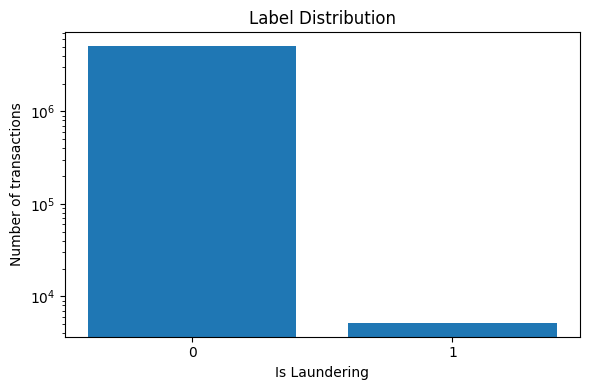

In [18]:
label_distribution_pd = label_distribution.to_pandas()

plt.figure(figsize=(6, 4))
plt.bar(
    label_distribution_pd["is_laundering"].astype(str),
    label_distribution_pd["count"],
)

plt.title("Label Distribution")
plt.xlabel("Is Laundering")
plt.ylabel("Number of transactions")
plt.yscale("log")
plt.tight_layout()
plt.show()

In [19]:
payment_format_summary = (
    transactions_clean
    .group_by("payment_format")
    .agg(
        [
            pl.len().alias("n_transactions"),
            pl.col("is_laundering").sum().alias("n_laundering"),
            (pl.col("is_laundering").mean() * 100)
            .round(4)
            .alias("laundering_rate_pct"),
        ]
    )
    .sort("n_transactions", descending=True)
)

payment_format_summary

payment_format,n_transactions,n_laundering,laundering_rate_pct
str,u32,i64,f64
"""Cheque""",1864331,324,0.0174
"""Credit Card""",1323324,206,0.0156
"""ACH""",600797,4483,0.7462
"""Cash""",490891,108,0.022
"""Reinvestment""",481056,0,0.0
"""Wire""",171855,0,0.0
"""Bitcoin""",146091,56,0.0383


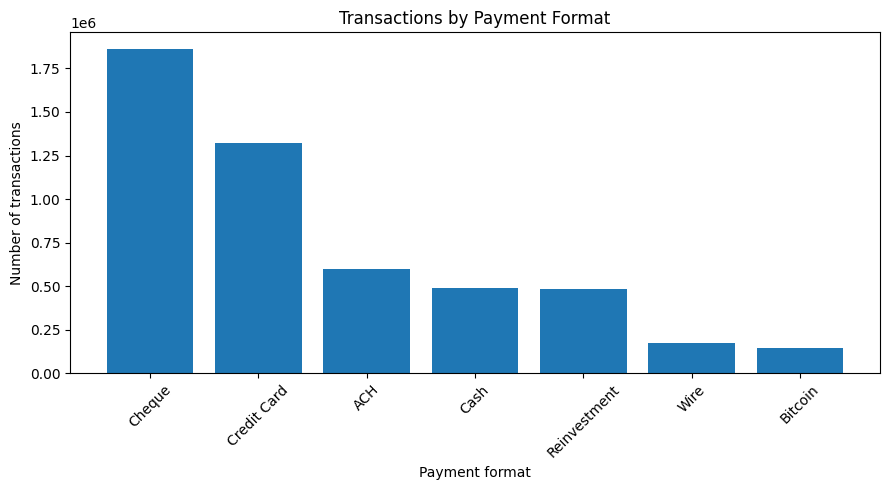

In [20]:
payment_format_pd = payment_format_summary.to_pandas()

plt.figure(figsize=(9, 5))
plt.bar(
    payment_format_pd["payment_format"],
    payment_format_pd["n_transactions"],
)

plt.title("Transactions by Payment Format")
plt.xlabel("Payment format")
plt.ylabel("Number of transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

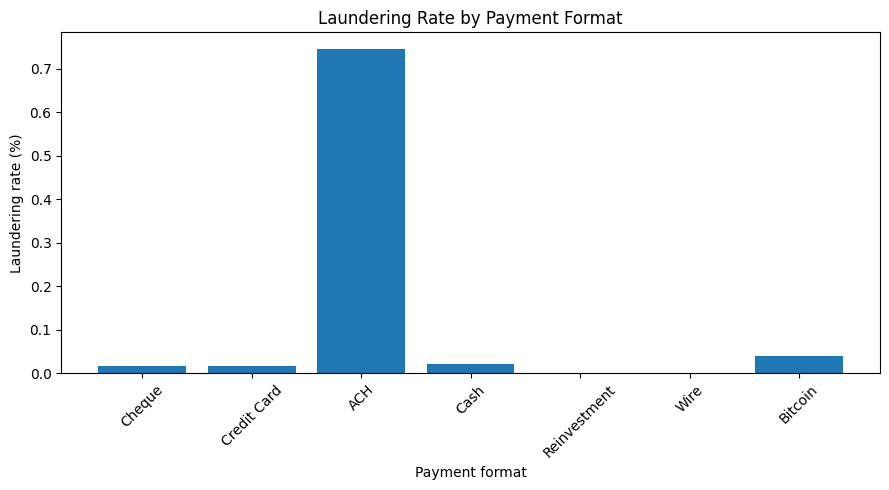

In [21]:
plt.figure(figsize=(9, 5))
plt.bar(
    payment_format_pd["payment_format"],
    payment_format_pd["laundering_rate_pct"],
)

plt.title("Laundering Rate by Payment Format")
plt.xlabel("Payment format")
plt.ylabel("Laundering rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
currency_summary = (
    transactions_clean
    .group_by("payment_currency")
    .agg(
        [
            pl.len().alias("n_transactions"),
            pl.col("is_laundering").sum().alias("n_laundering"),
            (pl.col("is_laundering").mean() * 100)
            .round(4)
            .alias("laundering_rate_pct"),
        ]
    )
    .sort("n_transactions", descending=True)
)

currency_summary

payment_currency,n_transactions,n_laundering,laundering_rate_pct
str,u32,i64,f64
"""US Dollar""",1895172,1912,0.1009
"""Euro""",1168297,1372,0.1174
"""Swiss Franc""",234860,193,0.0822
"""Yuan""",213752,184,0.0861
"""Shekel""",192184,95,0.0494
…,…,…,…
"""Canadian Dollar""",140042,128,0.0914
"""Australian Dollar""",136769,127,0.0929
"""Mexican Peso""",110159,92,0.0835


In [23]:
cross_currency_summary = (
    transactions_clean
    .group_by("is_cross_currency")
    .agg(
        [
            pl.len().alias("n_transactions"),
            pl.col("is_laundering").sum().alias("n_laundering"),
            (pl.col("is_laundering").mean() * 100)
            .round(4)
            .alias("laundering_rate_pct"),
        ]
    )
    .sort("is_cross_currency")
)

cross_currency_summary

is_cross_currency,n_transactions,n_laundering,laundering_rate_pct
i8,u32,i64,f64
0,5006175,5177,0.1034
1,72170,0,0.0


In [24]:
self_transfer_summary = (
    transactions_clean
    .group_by("is_self_transfer")
    .agg(
        [
            pl.len().alias("n_transactions"),
            pl.col("is_laundering").sum().alias("n_laundering"),
            (pl.col("is_laundering").mean() * 100)
            .round(4)
            .alias("laundering_rate_pct"),
        ]
    )
    .sort("is_self_transfer")
)

self_transfer_summary

is_self_transfer,n_transactions,n_laundering,laundering_rate_pct
i8,u32,i64,f64
0,4487133,5166,0.1151
1,591212,11,0.0019


In [25]:
self_transfer_by_format = (
    transactions_clean
    .group_by(["payment_format", "is_self_transfer"])
    .agg(
        [
            pl.len().alias("n_transactions"),
            pl.col("is_laundering").sum().alias("n_laundering"),
            (pl.col("is_laundering").mean() * 100)
            .round(4)
            .alias("laundering_rate_pct"),
        ]
    )
    .sort(["payment_format", "is_self_transfer"])
)

self_transfer_by_format

payment_format,is_self_transfer,n_transactions,n_laundering,laundering_rate_pct
str,i8,u32,i64,f64
"""ACH""",0,529450,4472,0.8447
"""ACH""",1,71347,11,0.0154
"""Bitcoin""",0,119774,56,0.0468
"""Bitcoin""",1,26317,0,0.0
"""Cash""",0,489436,108,0.0221
…,…,…,…,…
"""Credit Card""",0,1319148,206,0.0156
"""Credit Card""",1,4176,0,0.0
"""Reinvestment""",1,481056,0,0.0


In [26]:
amount_summary_by_label = (
    transactions_clean
    .group_by("is_laundering")
    .agg(
        [
            pl.col("amount_paid").count().alias("count"),
            pl.col("amount_paid").mean().round(2).alias("mean_amount"),
            pl.col("amount_paid").median().round(2).alias("median_amount"),
            pl.col("amount_paid").min().round(2).alias("min_amount"),
            pl.col("amount_paid").quantile(0.25).round(2).alias("q25_amount"),
            pl.col("amount_paid").quantile(0.75).round(2).alias("q75_amount"),
            pl.col("amount_paid").quantile(0.95).round(2).alias("q95_amount"),
            pl.col("amount_paid").max().round(2).alias("max_amount"),
        ]
    )
    .sort("is_laundering")
)

amount_summary_by_label

is_laundering,count,mean_amount,median_amount,min_amount,q25_amount,q75_amount,q95_amount,max_amount
i8,u32,f32,f32,f32,f32,f32,f32,f32
0,5073168,4.477e6,1410.98999,0.0,184.160004,12279.339844,623465.625,1.0463e12
1,5177,3.6135312e7,8667.209961,0.0,2634.969971,18832.269531,939548.0625,8.4853e10


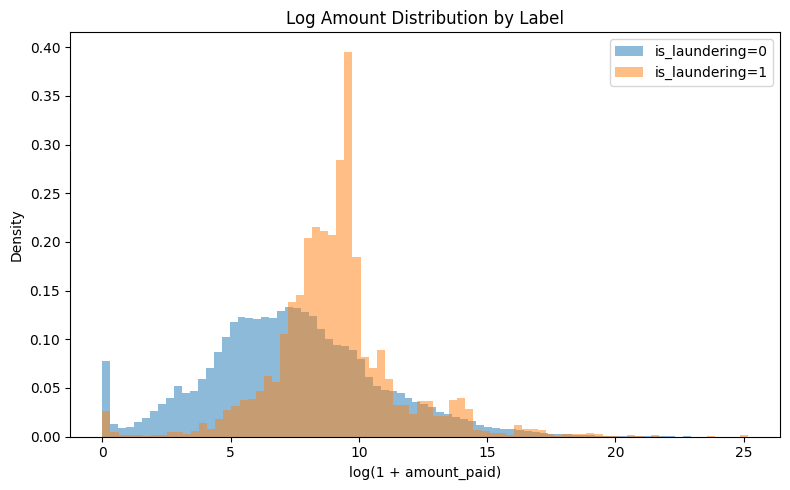

In [27]:
amount_plot_df = (
    pl.concat(
        [
            transactions_clean
            .filter(pl.col("is_laundering") == 0)
            .sample(n=200_000, seed=42),

            transactions_clean
            .filter(pl.col("is_laundering") == 1),
        ]
    )
    .select(["amount_paid", "is_laundering"])
    .to_pandas()
)

amount_plot_df["log_amount_paid"] = np.log1p(amount_plot_df["amount_paid"])

plt.figure(figsize=(8, 5))

for label in [0, 1]:
    subset = amount_plot_df[amount_plot_df["is_laundering"] == label]

    plt.hist(
        subset["log_amount_paid"],
        bins=80,
        alpha=0.5,
        density=True,
        label=f"is_laundering={label}",
    )

plt.title("Log Amount Distribution by Label")
plt.xlabel("log(1 + amount_paid)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
transactions_by_day = (
    transactions_clean
    .with_columns(
        pl.col("timestamp").dt.date().alias("date")
    )
    .group_by("date")
    .agg(
        [
            pl.len().alias("n_transactions"),
            pl.col("is_laundering").sum().alias("n_laundering"),
            (pl.col("is_laundering").mean() * 100)
            .round(4)
            .alias("laundering_rate_pct"),
        ]
    )
    .sort("date")
)

transactions_by_day

date,n_transactions,n_laundering,laundering_rate_pct
date,u32,i64,f64
2022-09-01,1114921,322,0.0289
2022-09-02,754449,408,0.0541
2022-09-03,207382,391,0.1885
2022-09-04,207430,407,0.1962
2022-09-05,482650,471,0.0976
…,…,…,…
2022-09-14,121,70,57.8512
2022-09-15,46,28,60.8696
2022-09-16,46,26,56.5217


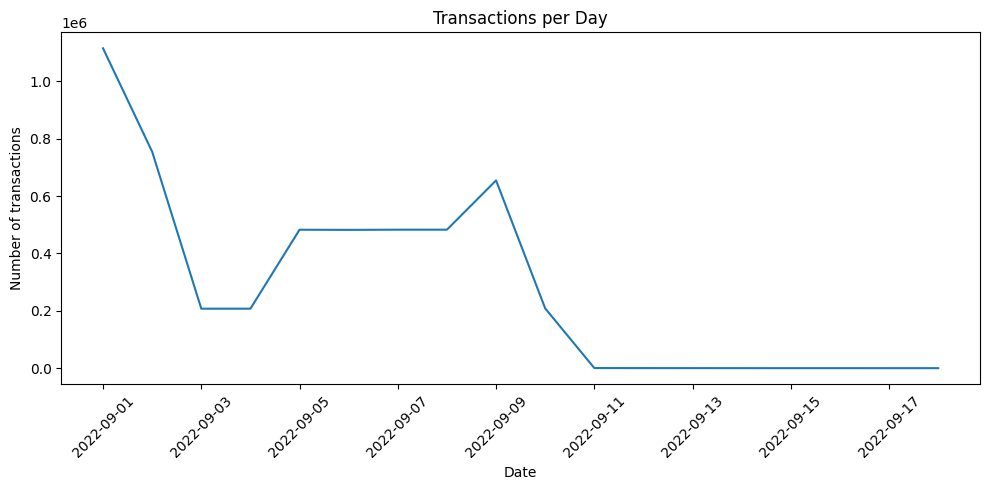

In [29]:
transactions_by_day_pd = transactions_by_day.to_pandas()

plt.figure(figsize=(10, 5))
plt.plot(
    transactions_by_day_pd["date"],
    transactions_by_day_pd["n_transactions"],
)

plt.title("Transactions per Day")
plt.xlabel("Date")
plt.ylabel("Number of transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

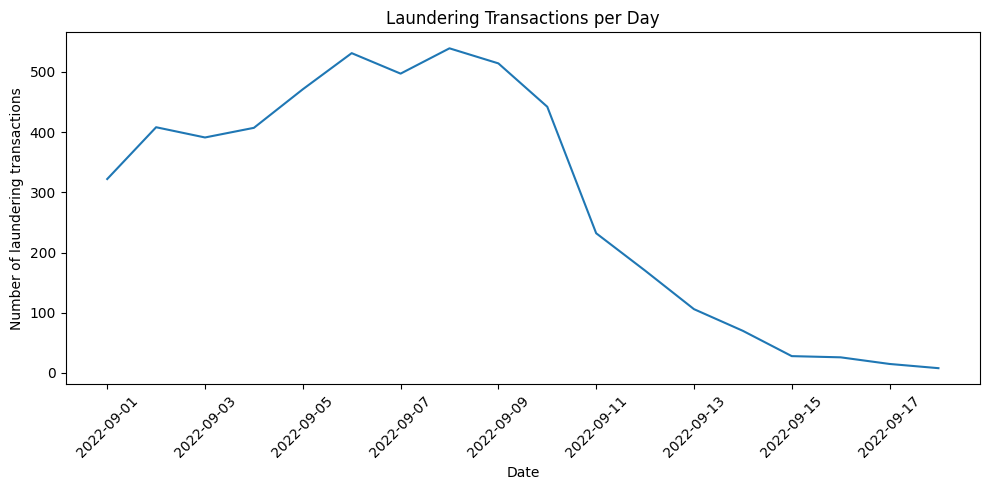

In [30]:
plt.figure(figsize=(10, 5))
plt.plot(
    transactions_by_day_pd["date"],
    transactions_by_day_pd["n_laundering"],
)

plt.title("Laundering Transactions per Day")
plt.xlabel("Date")
plt.ylabel("Number of laundering transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()